<a href="https://colab.research.google.com/github/devisheshamalinis2449sse-sudo/Machine-learning/blob/main/5th_Exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully.
['setosa' 'versicolor' 'virginica']
Total samples: 150, Total features: 4

K-NN Classifier trained successfully with K = 5.

=== CONFUSION MATRIX ===
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Overall Accuracy of the Model: 100.00%

Close the plot window to finish the program execution.


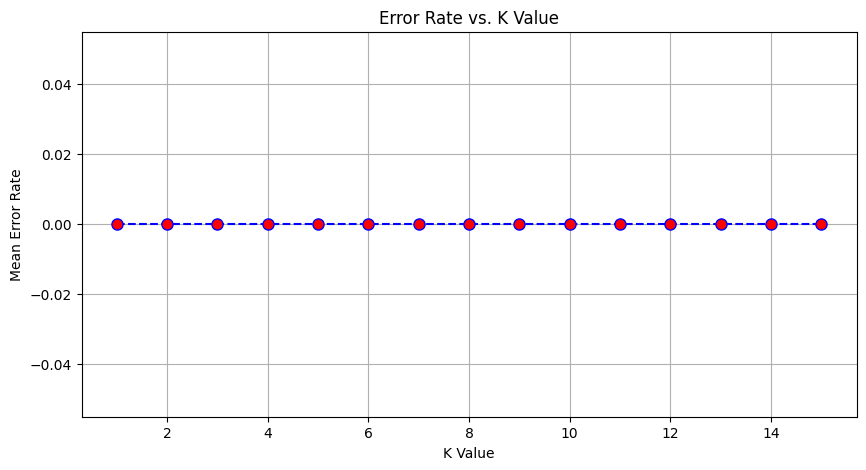

In [2]:
# =====================================================================
# LAB EXPERIMENT: Implementation of K-Nearest Neighbours (K-NN)
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the Dataset
# We use the Iris dataset (features: sepal/petal length & width)
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset loaded successfully.")
print(class_names := iris.target_names)
print(f"Total samples: {X.shape[0]}, Total features: {X.shape[1]}\n")

# 2. Split the Dataset into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Feature Scaling (Crucial for K-NN because it relies on Euclidean distance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Initialize and Train the K-NN Classifier
# We choose K=5 as a starting standard
k_value = 5
knn = KNeighborsClassifier(n_neighbors=k_value)
knn.fit(X_train, y_train)
print(f"K-NN Classifier trained successfully with K = {k_value}.\n")

# 5. Make Predictions on the Test Data
y_pred = knn.predict(X_test)

# 6. Evaluate the Model's Performance
print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Overall Accuracy of the Model: {accuracy:.2f}%")

# =====================================================================
# BONUS: Finding the Optimal K-Value (Error Rate Plot)
# =====================================================================
error_rate = []

# Calculating error for K values from 1 to 15
for i in range(1, 16):
    knn_i = KNeighborsClassifier(n_neighbors=i)
    knn_i.fit(X_train, y_train)
    pred_i = knn_i.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting the error rate
plt.figure(figsize=(10, 5))
plt.plot(range(1, 16), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error Rate')
plt.grid(True)
print("\nClose the plot window to finish the program execution.")
plt.show()